## Exploratory Data Analysis: Xente Credit Risk Dataset
**Task 2 | Bati Bank Buy-Now-Pay-Later Credit Scoring Project**

Objective: Explore the dataset to uncover patterns, identify data quality 
issues, and form hypotheses to guide feature engineering.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

In [3]:
DATA_PATH = "../data/raw/data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["TransactionStartTime"])
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 95,662 rows × 16 columns


### 1. Overview of the Data

Understand the structure of the dataset: number of rows, columns, and data types.

In [4]:
print("=" * 50)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 50)
print()
print(df.dtypes.to_string())

  Rows    : 95,662
  Columns : 16

TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64


In [5]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [6]:
info_rows = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    info_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "null_count": null_count,
        "null_pct": round(null_count / len(df) * 100, 2),
        "unique_count": df[col].nunique(),
        "sample_value": df[col].dropna().iloc[0] if df[col].notna().any() else None,
    })

pd.DataFrame(info_rows).style.set_caption("Column Inventory")

,column,dtype,null_count,null_pct,unique_count,sample_value
0,TransactionId,object,0,0.000000,95662,TransactionId_76871
1,BatchId,object,0,0.000000,94809,BatchId_36123
2,AccountId,object,0,0.000000,3633,AccountId_3957
3,SubscriptionId,object,0,0.000000,3627,SubscriptionId_887
4,CustomerId,object,0,0.000000,3742,CustomerId_4406
5,CurrencyCode,object,0,0.000000,1,UGX
6,CountryCode,int64,0,0.000000,1,256
7,ProviderId,object,0,0.000000,6,ProviderId_6
8,ProductId,object,0,0.000000,23,ProductId_10
9,ProductCategory,object,0,0.000000,9,airtime


### 2. Summary Statistics

Central tendency, dispersion, and shape of numerical feature distributions.

In [7]:
num_cols = ["Amount", "Value", "PricingStrategy", "FraudResult"]
df[num_cols].describe().T.style.format("{:.2f}").set_caption("Numerical Summary Statistics")

,count,mean,std,min,25%,50%,75%,max
Amount,95662.00,6717.85,123306.80,-1000000.00,-50.00,1000.00,2800.00,9880000.00
Value,95662.00,9900.58,123122.09,2.00,275.00,1000.00,5000.00,9880000.00
PricingStrategy,95662.00,2.26,0.73,0.00,2.00,2.00,2.00,4.00
FraudResult,95662.00,0.00,0.04,0.00,0.00,0.00,0.00,1.00


In [8]:
skew_kurt = pd.DataFrame({
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurt(),
})
print("Skewness & Kurtosis:")
print(skew_kurt.round(2).to_string())

Skewness & Kurtosis:
                 skewness  kurtosis
Amount              51.10   3363.13
Value               51.29   3378.07
PricingStrategy      1.66      2.09
FraudResult         22.20    490.69


**Observations:**
- `Amount` spans large negatives (credits) to large positives (debits), bidirectional.
- `Value` is always the absolute amount, minimum is always > 0.
- `FraudResult` is heavily imbalanced (~0.2% fraud). Accuracy is a misleading metric.
- `CountryCode` is constant (256 = Uganda) zero-variance, drop in feature engineering.

### 3. Distribution of Numerical Features

Visualize distributions to identify skewness, modality, and potential outliers.

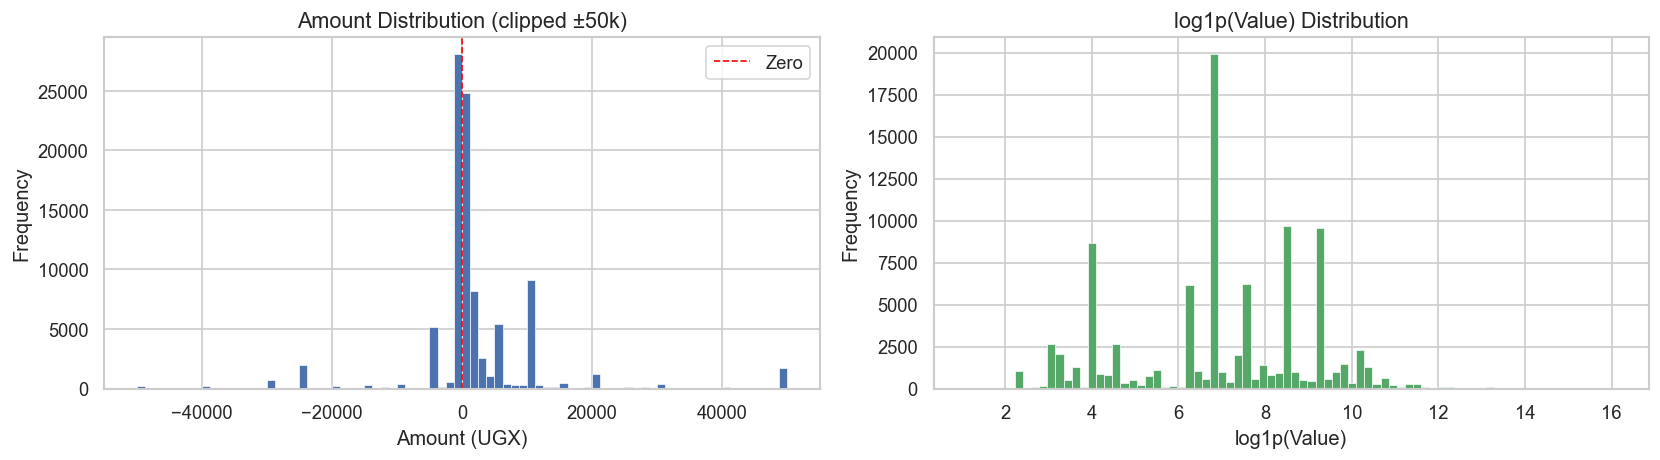

Negative Amount : 38,189  (39.9%)
Zero Amount     : 0
Positive Amount : 57,473  (60.1%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Amount"].clip(-50_000, 50_000), bins=80,
             color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].set_title("Amount Distribution (clipped ±50k)", fontsize=13)
axes[0].set_xlabel("Amount (UGX)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="Zero")
axes[0].legend()

axes[1].hist(np.log1p(df["Value"]), bins=80,
             color="#55A868", edgecolor="white", linewidth=0.4)
axes[1].set_title("log1p(Value) Distribution", fontsize=13)
axes[1].set_xlabel("log1p(Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Negative Amount : {(df['Amount'] < 0).sum():,}  ({(df['Amount'] < 0).mean()*100:.1f}%)")
print(f"Zero Amount     : {(df['Amount'] == 0).sum():,}")
print(f"Positive Amount : {(df['Amount'] > 0).sum():,}  ({(df['Amount'] > 0).mean()*100:.1f}%)")

Figure 1: Amount & Value Distributions
The Amount distribution is extremely concentrated near zero with a sharp peak, confirming that most transactions are small-value. A visible left tail shows a meaningful number of negative (credit) transactions reaching as low as −40,000 UGX. The log1p(Value) distribution is discrete and multimodal rather than smooth, suggesting that transaction values cluster around specific fixed amounts (e.g. standard airtime top-up denominations) rather than varying continuously.

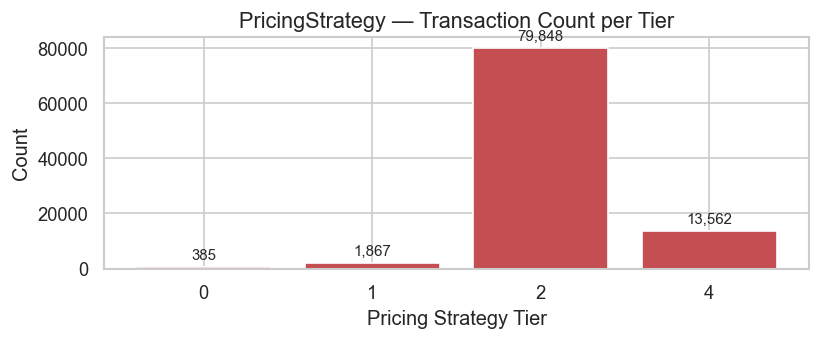

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
pricing_counts = df["PricingStrategy"].value_counts().sort_index()
bars = ax.bar(pricing_counts.index.astype(str), pricing_counts.values,
              color="#C44E52", edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.set_title("PricingStrategy — Transaction Count per Tier", fontsize=13)
ax.set_xlabel("Pricing Strategy Tier")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Figure 2: PricingStrategy Distribution
Pricing Strategy Tier 2 dominates overwhelmingly with 79,848 transactions (83.5% of all data), while Tiers 0, 1, and 4 together account for only 15,814. Tier 3 is entirely absent. This near-constant distribution means PricingStrategy has very low variance and will likely contribute minimal predictive signal as a raw feature.

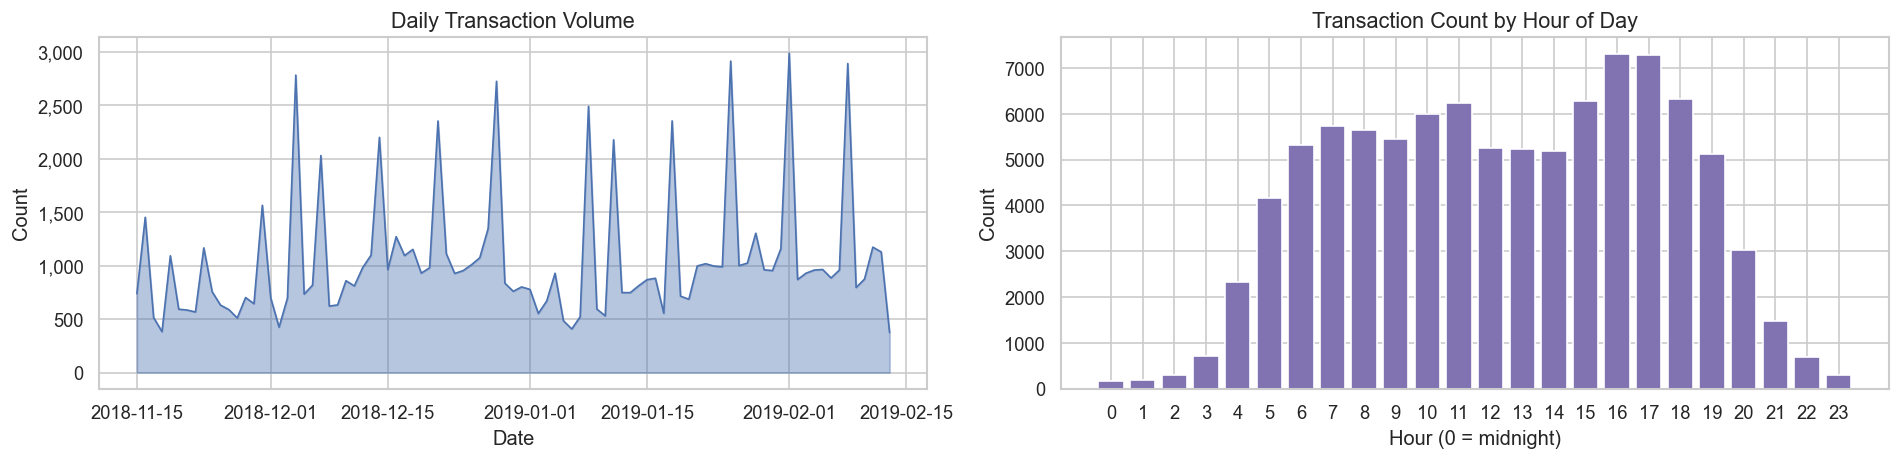

Date range : 2018-11-15 → 2019-02-13
Duration   : 90 days


In [11]:
df["transaction_hour"] = df["TransactionStartTime"].dt.hour
df["transaction_day_of_week"] = df["TransactionStartTime"].dt.dayofweek

daily = df.set_index("TransactionStartTime").resample("D")["TransactionId"].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].fill_between(daily.index, daily.values, alpha=0.4, color="#4C72B0")
axes[0].plot(daily.index, daily.values, color="#4C72B0", linewidth=1)
axes[0].set_title("Daily Transaction Volume", fontsize=13)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

hour_counts = df["transaction_hour"].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color="#8172B2", edgecolor="white")
axes[1].set_title("Transaction Count by Hour of Day", fontsize=13)
axes[1].set_xlabel("Hour (0 = midnight)")
axes[1].set_ylabel("Count")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print(f"Date range : {df['TransactionStartTime'].min().date()} → {df['TransactionStartTime'].max().date()}")
print(f"Duration   : {(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days} days")

Figure 3: Daily Transaction Volume & Hour-of-Day Pattern
The daily volume chart spans November 2018 to February 2019 and shows recurring sharp spikes roughly every 7–10 days, suggesting periodic batch events or promotional campaigns rather than purely organic activity. The hour-of-day chart reveals a clear business-hours pattern: activity is negligible between midnight and 4 AM, ramps up sharply from 5 AM, peaks at 16:00–17:00 (4–5 PM), and drops off steeply after 20:00. This confirms that transaction_hour is a meaningful feature.

### 4. Distribution of Categorical Features

Frequency and variability of each categorical column.

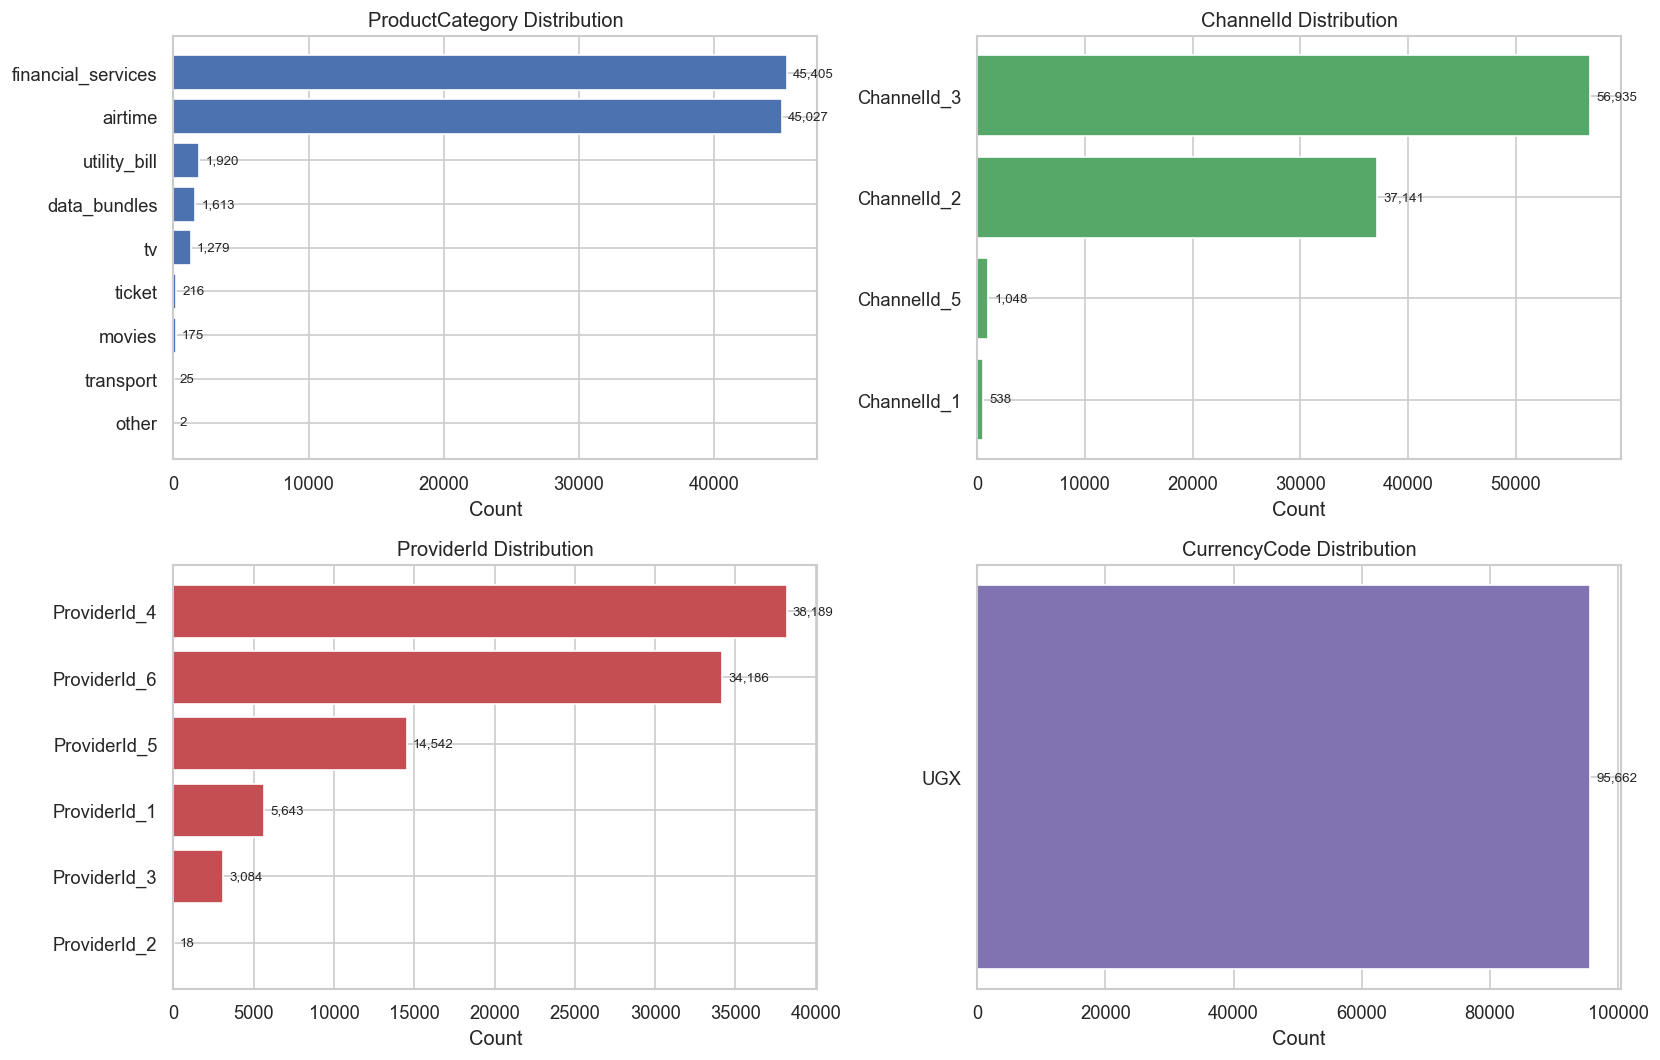

In [12]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "CurrencyCode"]
colors   = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=colors[i], edgecolor="white")
    for j, v in enumerate(counts.values):
        axes[i].text(v + counts.values.max() * 0.01, j,
                     f"{v:,}", va="center", fontsize=8)
    axes[i].set_title(f"{col} Distribution", fontsize=12)
    axes[i].set_xlabel("Count")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

Figure 4: Categorical Feature Distributions
financial_services (45,405) and airtime (45,027) together account for over 94% of all transactions, with all other categories being minor. ChannelId_3 is the dominant channel (56,935 transactions), followed by ChannelId_2 (37,141). ProviderId_4 and ProviderId_6 handle the bulk of transactions. Critically, CurrencyCode is entirely UGX, a zero-variance column with no predictive value that must be dropped in Task 3.

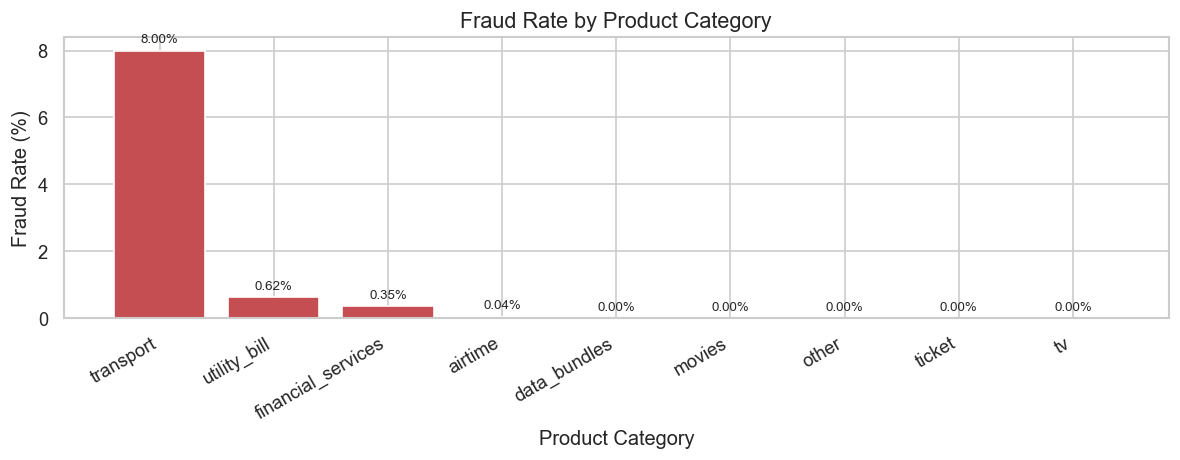

                    total  fraud  fraud_rate
ProductCategory                             
transport              25      2    8.000000
utility_bill         1920     12    0.625000
financial_services  45405    161    0.354586
airtime             45027     18    0.039976
data_bundles         1613      0    0.000000
movies                175      0    0.000000
other                   2      0    0.000000
ticket                216      0    0.000000
tv                   1279      0    0.000000


In [13]:
fraud_by_cat = (
    df.groupby("ProductCategory")["FraudResult"]
    .agg(total="count", fraud="sum")
    .assign(fraud_rate=lambda x: x["fraud"] / x["total"] * 100)
    .sort_values("fraud_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(fraud_by_cat.index, fraud_by_cat["fraud_rate"],
              color="#C44E52", edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}%", padding=3, fontsize=8)
ax.set_title("Fraud Rate by Product Category", fontsize=13)
ax.set_ylabel("Fraud Rate (%)")
ax.set_xlabel("Product Category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(fraud_by_cat.to_string())

Figure 5: Fraud Rate by Product Category
transport has by far the highest fraud rate at 8.00%, despite having only 25 transactions, making it statistically unreliable but worth flagging. utility_bill (0.62%) and financial_services (0.35%) are the only high-volume categories with a non-trivial fraud rate. airtime, the highest-volume category, has a near-zero fraud rate (0.04%). This uneven fraud distribution across categories strongly supports using WoE encoding for ProductCategory rather than one-hot encoding.

### 5. Correlation Analysis

Understand the linear relationships between numerical features.

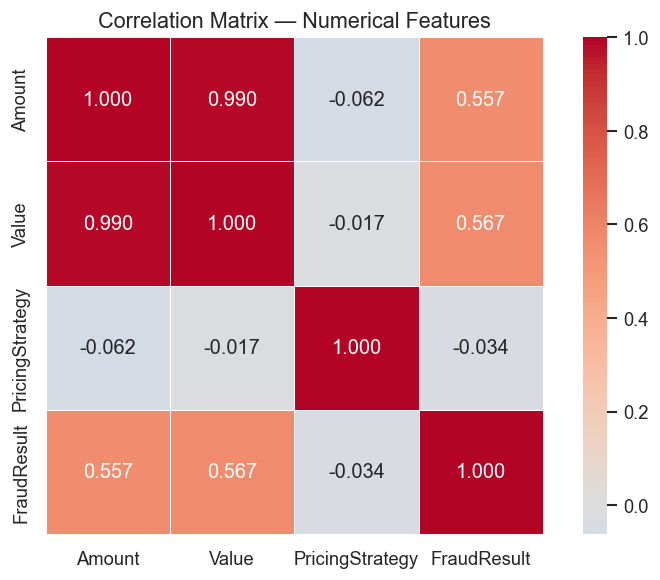

In [14]:
corr_cols   = ["Amount", "Value", "PricingStrategy", "FraudResult"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax, square=True,
)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

Figure 6: Correlation Matrix
Amount and Value are nearly perfectly correlated (r = 0.990), confirming they carry near-identical information, one should be dropped or only the absolute value used. Both Amount (r = 0.557) and Value (r = 0.567) show a moderate positive correlation with FraudResult, meaning higher-value transactions are associated with higher fraud probability. PricingStrategy is essentially uncorrelated with all other features.

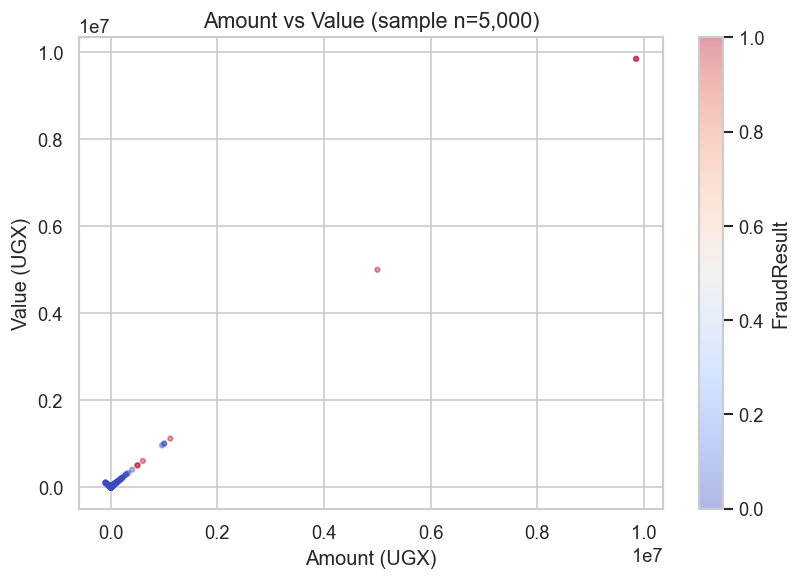

Pearson correlation (Amount vs Value): 0.9897


In [15]:
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    sample["Amount"], sample["Value"],
    c=sample["FraudResult"], cmap="coolwarm",
    alpha=0.4, s=8,
)
plt.colorbar(scatter, ax=ax, label="FraudResult")
ax.set_title("Amount vs Value (sample n=5,000)", fontsize=13)
ax.set_xlabel("Amount (UGX)")
ax.set_ylabel("Value (UGX)")
plt.tight_layout()
plt.show()

print("Pearson correlation (Amount vs Value):", df["Amount"].corr(df["Value"]).round(4))

Figure 7: Amount vs Value Scatter (n=5,000)
The scatter plot reveals two extreme outliers, one transaction exceeding 10M UGX in both Amount and Value (flagged as fraud, shown in pink), and another around 5M UGX, that pull the axis scale dramatically and compress all other data into the bottom-left corner. This visually confirms the severity of the outlier problem identified in the IQR analysis and reinforces the need for log transformation or outlier capping before any distance-based computation.

### 6. Identifying Missing Values

Check for missing data across all columns and plan imputation strategies.

In [16]:
missing = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
}).sort_values("null_count", ascending=False)

print(missing.to_string())
print()
if missing["null_count"].sum() == 0:
    print(" No missing values detected in any column.")
else:
    print(" Missing values found, see table above.")

                         null_count  null_pct
TransactionId                     0       0.0
BatchId                           0       0.0
transaction_hour                  0       0.0
FraudResult                       0       0.0
PricingStrategy                   0       0.0
TransactionStartTime              0       0.0
Value                             0       0.0
Amount                            0       0.0
ChannelId                         0       0.0
ProductCategory                   0       0.0
ProductId                         0       0.0
ProviderId                        0       0.0
CountryCode                       0       0.0
CurrencyCode                      0       0.0
CustomerId                        0       0.0
SubscriptionId                    0       0.0
AccountId                         0       0.0
transaction_day_of_week           0       0.0

 No missing values detected in any column.


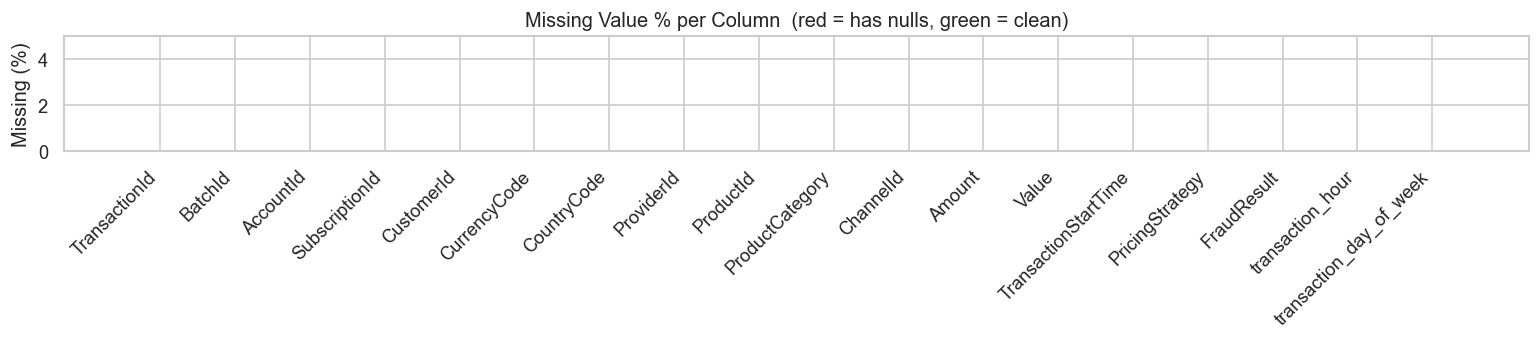

In [17]:
miss_vals   = df.isnull().mean() * 100
colors_miss = ["#C44E52" if v > 0 else "#55A868" for v in miss_vals]

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(miss_vals.index, miss_vals.values, color=colors_miss, edgecolor="white")
ax.set_title("Missing Value % per Column  (red = has nulls, green = clean)", fontsize=12)
ax.set_ylabel("Missing (%)")
ax.set_ylim(0, max(miss_vals.max() + 2, 5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Figure 8: Missing Values per Column
Every bar sits at exactly 0%, confirming that the dataset has no missing values across all 21 columns (including the 5 temporal features extracted in Cell 14). No imputation strategy is required for the raw data, though structural nulls may arise after customer-level aggregation in Task 4.

### 7. Outlier Detection

Use box plots and IQR fences to identify extreme values.

In [18]:
def iqr_outlier_summary(df, columns):
    rows = []
    for col in columns:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            "column": col,
            "outlier_count": n_out,
            "outlier_pct": round(n_out / len(df) * 100, 2),
            "lower_fence": round(lower, 2),
            "upper_fence": round(upper, 2),
        })
    return pd.DataFrame(rows).set_index("column")

iqr_outlier_summary(df, ["Amount", "Value"])

,outlier_count,outlier_pct,lower_fence,upper_fence
column,,,,
Amount,24441,25.55,-4325.0,7075.0
Value,9021,9.43,-6812.5,12087.5


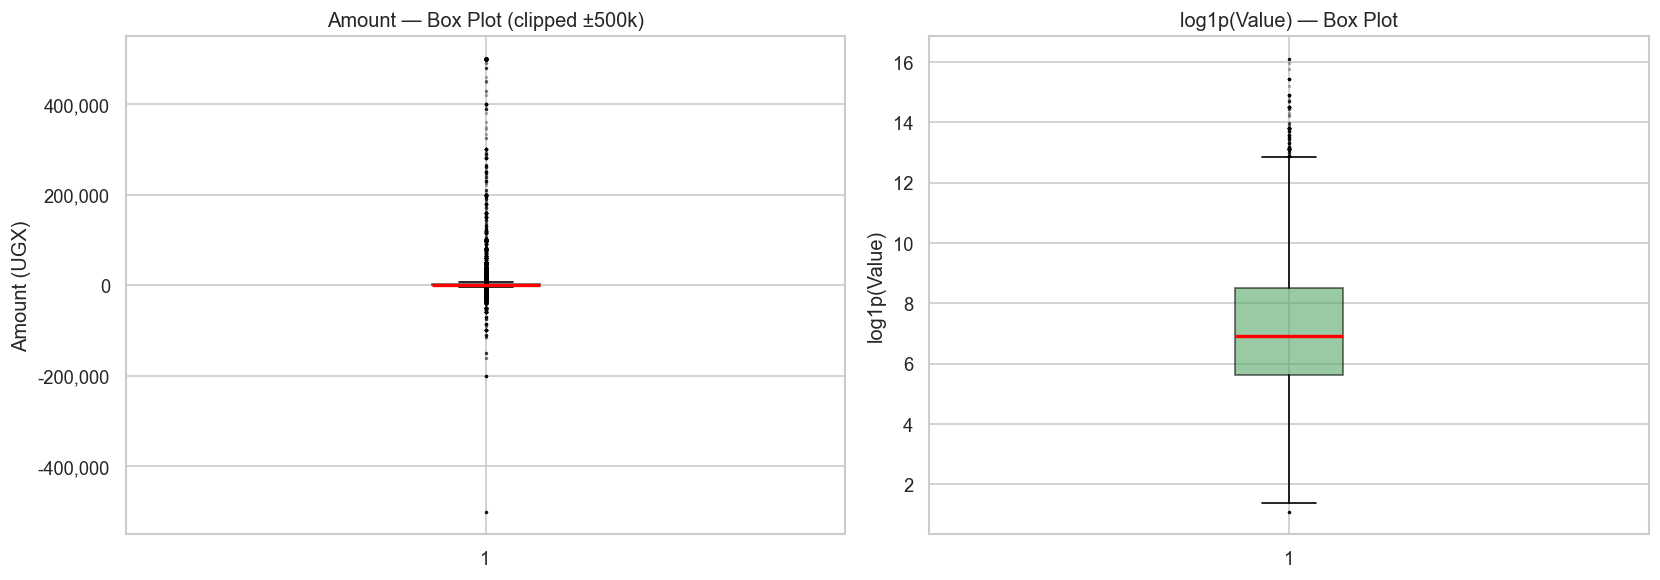

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df["Amount"].clip(-500_000, 500_000), vert=True, patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
axes[0].set_title("Amount — Box Plot (clipped ±500k)", fontsize=12)
axes[0].set_ylabel("Amount (UGX)")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].boxplot(
    np.log1p(df["Value"]), vert=True, patch_artist=True,
    boxprops=dict(facecolor="#55A868", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
axes[1].set_title("log1p(Value) — Box Plot", fontsize=12)
axes[1].set_ylabel("log1p(Value)")

plt.tight_layout()
plt.show()

Figure 9: Amount & Value Box Plots
The Amount box plot shows an extremely compressed IQR near zero with massive outliers extending to ±500,000 UGX, confirming the distribution is dominated by low-value transactions with a heavy-tailed minority. The log1p(Value) box plot is much better behaved after transformation, the IQR spans roughly 6 to 8.5 but still shows outliers extending to 16 (corresponding to values in the tens of millions UGX), confirming that log transformation alone is insufficient to fully handle extremes.

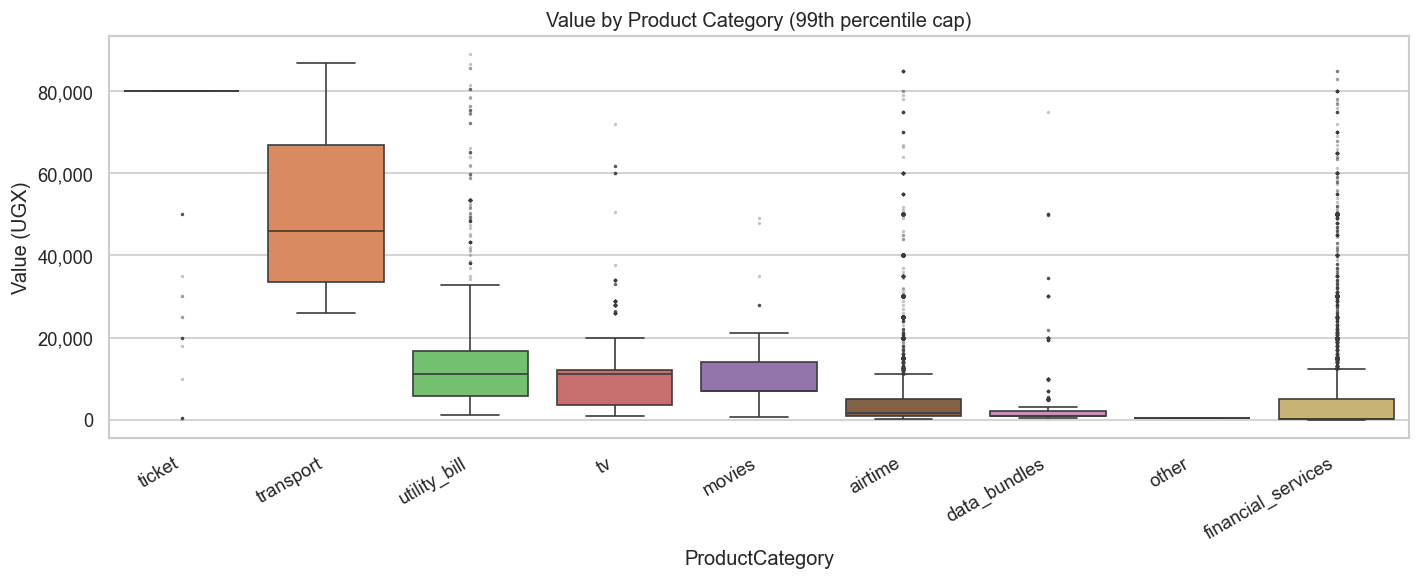

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
cat_order = (df.groupby("ProductCategory")["Value"]
               .median()
               .sort_values(ascending=False)
               .index)
df_plot = df[df["Value"] < df["Value"].quantile(0.99)]

sns.boxplot(
    data=df_plot, x="ProductCategory", y="Value",
    order=cat_order, palette="muted", ax=ax,
    flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
)
ax.set_title("Value by Product Category (99th percentile cap)", fontsize=12)
ax.set_ylabel("Value (UGX)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Figure 10: Value by Product Category (Box Plot)
transport has the highest median transaction value (~45,000 UGX) and widest IQR, consistent with its high fraud rate. ticket shows an extreme outlier above 80,000 UGX despite zero fraud. financial_services has a low median but an extremely long upper tail with many high-value outliers, this combination of high volume, moderate fraud rate, and heavy tail makes it the most complex category to model. airtime and data_bundles are tightly clustered at low values with minimal spread, reflecting fixed-denomination top-up products.

### Key Insights Summary

### Insight 1: Severe Class Imbalance in FraudResult
Only ~0.2% of transactions are flagged as fraud (193 / 95,662). Accuracy is a
misleading metric. Any model must use class weighting or stratified sampling.
F1 and Precision-Recall AUC are the correct evaluation metrics.

### Insight 2: Amount Is Bidirectional; Value Is Always Positive
`Amount` contains both negative (credits) and positive (debits) values. The sign
of Amount is itself a meaningful feature. `Value` is always the absolute amount.
Using raw `Amount` in distance-based models (e.g. KMeans for RFM) without handling
the sign will produce misleading clusters.

### Insight 3: Extreme Outliers Require Log Transformation
Both `Amount` and `Value` are highly right-skewed with heavy tails. A small number
of transactions reach into the tens of millions UGX. Feature engineering must apply
`log1p` transformation and/or robust scaling before any model training.

### Insight 4: Strong Temporal Patterns Exist
Activity peaks at 16:00–17:00 and is near-zero between midnight and 4 AM.
Daily volume shows recurring spikes every 7–10 days suggesting periodic batch
events. `transaction_hour` and `transaction_day_of_week` carry predictive signal
and must be extracted as features in Task 3.

### Insight 5: ProductCategory Drives Fraud Rate Unevenly
`transport` has an 8% fraud rate; `financial_services` 0.35%; `airtime` near zero.
This uneven distribution across categories means WoE encoding per category will
capture the risk gradient far better than naive one-hot encoding.

**Zero missing values** found across all columns. No imputation required.
`CountryCode` is zero-variance (constant = 256) drop in Task 3.